# Diffusion Model (DDPM) - PyTorch


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


Epoch 1, Loss: 0.2560
Epoch 2, Loss: 0.1480
Epoch 3, Loss: 0.1274
Epoch 4, Loss: 0.1440
Epoch 5, Loss: 0.1042
Epoch 6, Loss: 0.1021
Epoch 7, Loss: 0.0969
Epoch 8, Loss: 0.0875
Epoch 9, Loss: 0.1166
Epoch 10, Loss: 0.1074
Epoch 11, Loss: 0.0877
Epoch 12, Loss: 0.0972
Epoch 13, Loss: 0.1123
Epoch 14, Loss: 0.0981
Epoch 15, Loss: 0.0820
Epoch 16, Loss: 0.0806
Epoch 17, Loss: 0.0840
Epoch 18, Loss: 0.0841
Epoch 19, Loss: 0.0821
Epoch 20, Loss: 0.0804


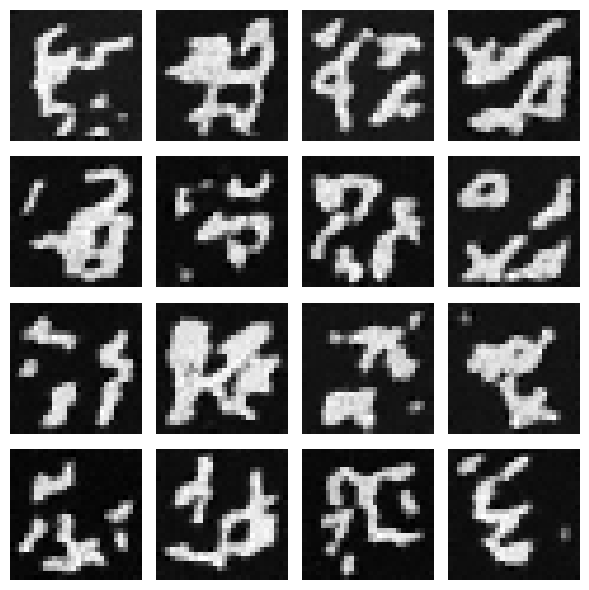

Using device: cuda
Starting training...
Epoch 01/20 | Train MSE Loss: 0.33425
Epoch 02/20 | Train MSE Loss: 0.18618
Epoch 03/20 | Train MSE Loss: 0.14677
Epoch 04/20 | Train MSE Loss: 0.12598
Epoch 05/20 | Train MSE Loss: 0.11501
Epoch 06/20 | Train MSE Loss: 0.10438
Epoch 07/20 | Train MSE Loss: 0.09829
Epoch 08/20 | Train MSE Loss: 0.09303


In [ ]:
# =========================================
# 1. Imports
# =========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"


# =========================================
# 2. Load Dataset (MNIST)
# =========================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0)  # [-1,1]
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


# =========================================
# 3. Diffusion Hyperparameters
# =========================================
timesteps = 200

betas = torch.linspace(1e-4, 0.02, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)


# =========================================
# 4. Helper: Add Noise
# =========================================
def add_noise(x, t):
    noise = torch.randn_like(x)

    sqrt_alpha = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    return sqrt_alpha * x + sqrt_one_minus * noise, noise


# =========================================
# 5. Simple U-Net Model
# =========================================
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_embed = nn.Embedding(timesteps, 32)
        self.fc_time = nn.Linear(32, 32)

        # Down
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)

        # Middle
        self.conv3 = nn.Conv2d(64 + 32, 64, 3, padding=1)

        # Up
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.out = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_embed(t)
        t_emb = F.relu(self.fc_time(t_emb))
        t_emb = t_emb.view(-1, 32, 1, 1)

        # Down
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))  # (B,64,14,14)

        # Broadcast time embedding
        t_broadcast = t_emb.expand(-1, -1, 14, 14)

        # Concatenate
        x = torch.cat([x2, t_broadcast], dim=1)

        # Middle
        x = F.relu(self.conv3(x))

        # Up
        x = F.relu(self.conv4(x))

        return self.out(x)


model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# =========================================
# 6. Training Step
# =========================================
def train_step(x):
    x = x.to(device)
    t = torch.randint(0, timesteps, (x.size(0),), device=device)
    x_noisy, noise = add_noise(x, t)
    noise_pred = model(x_noisy, t)

    loss = F.mse_loss(noise_pred, noise)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


# =========================================
# 7. Training Loop
# =========================================
epochs = 20

for epoch in range(epochs):
    for batch, _ in dataloader:
        loss = train_step(batch)

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")


# =========================================
# 8. Sampling (Reverse Diffusion)
# =========================================
@torch.no_grad()
def sample_images(num_images=16):
    x = torch.randn((num_images, 1, 28, 28), device=device)

    for t in reversed(range(timesteps)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        noise_pred = model(x, t_batch)

        alpha = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta = betas[t]

        x = (1 / torch.sqrt(alpha)) * (
            x - (1 - alpha) / torch.sqrt(1 - alpha_cumprod_t) * noise_pred
        )

        if t > 0:
            x += torch.sqrt(beta) * torch.randn_like(x)

    return x


# =========================================
# 9. Visualization
# =========================================
generated = sample_images(16).cpu()
generated = (generated + 1) / 2.0

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()# =========================================
# 1. Imports
# =========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducible results
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# =========================================
# 2. Load Dataset (MNIST)
# =========================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0)  # Scale to [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True if device == "cuda" else False
)

# =========================================
# 3. Diffusion Hyperparameters
# =========================================
timesteps = 200

betas = torch.linspace(1e-4, 0.02, timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# =========================================
# 4. Helper: Add Noise
# =========================================
def add_noise(x, t):
    noise = torch.randn_like(x)

    sqrt_alpha = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    return sqrt_alpha * x + sqrt_one_minus * noise, noise

# =========================================
# 5. Enhanced U-Net Model
# =========================================
class ImprovedUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Time Embedding
        self.time_embed = nn.Embedding(timesteps, 64)
        self.fc_time = nn.Linear(64, 64)

        # --- Downsampling Path ---
        # Level 1: 28x28
        self.down1 = nn.Conv2d(1, 32, 3, padding=1)
        self.time_proj1 = nn.Linear(64, 32)

        # Level 2: 14x14
        self.down2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.time_proj2 = nn.Linear(64, 64)

        # --- Bottleneck ---
        # Level 3: 7x7
        self.mid_conv1 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.mid_conv2 = nn.Conv2d(128, 128, 3, padding=1)

        # --- Upsampling Path ---
        # Up Level 2: 14x14
        self.up1_trans = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        # 64 (upsampled) + 64 (skip connection from down2) = 128 channels in
        self.up1_conv = nn.Conv2d(128, 64, 3, padding=1)
        self.time_proj_up1 = nn.Linear(64, 64)

        # Up Level 1: 28x28
        self.up2_trans = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        # 32 (upsampled) + 32 (skip connection from down1) = 64 channels in
        self.up2_conv = nn.Conv2d(64, 32, 3, padding=1)
        self.time_proj_up2 = nn.Linear(64, 32)

        # Output
        self.out = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, t):
        # Time embedding
        t_emb = F.silu(self.time_embed(t))
        t_emb = self.fc_time(t_emb)

        # Down 1
        x1 = self.down1(x)
        x1 = x1 + self.time_proj1(t_emb).view(-1, 32, 1, 1)
        x1 = F.silu(x1)

        # Down 2
        x2 = self.down2(x1)
        x2 = x2 + self.time_proj2(t_emb).view(-1, 64, 1, 1)
        x2 = F.silu(x2)

        # Bottleneck
        x3 = F.silu(self.mid_conv1(x2))
        x3 = F.silu(self.mid_conv2(x3))

        # Up 1
        x_up1 = self.up1_trans(x3)
        x_up1 = torch.cat([x_up1, x2], dim=1)  # Skip connection
        x_up1 = self.up1_conv(x_up1)
        x_up1 = x_up1 + self.time_proj_up1(t_emb).view(-1, 64, 1, 1)
        x_up1 = F.silu(x_up1)

        # Up 2
        x_up2 = self.up2_trans(x_up1)
        x_up2 = torch.cat([x_up2, x1], dim=1)  # Skip connection
        x_up2 = self.up2_conv(x_up2)
        x_up2 = x_up2 + self.time_proj_up2(t_emb).view(-1, 32, 1, 1)
        x_up2 = F.silu(x_up2)

        return self.out(x_up2)

model = ImprovedUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# =========================================
# 6. Training Step
# =========================================
def train_step(x):
    x = x.to(device)
    t = torch.randint(0, timesteps, (x.size(0),), device=device)
    x_noisy, noise = add_noise(x, t)

    noise_pred = model(x_noisy, t)
    loss = F.mse_loss(noise_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# =========================================
# 7. Training Loop
# =========================================
epochs = 20

print("Starting training...")
for epoch in range(epochs):
    epoch_losses = []
    model.train()

    for batch, _ in dataloader:
        loss = train_step(batch)
        epoch_losses.append(loss)

    mean_loss = np.mean(epoch_losses)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train MSE Loss: {mean_loss:.5f}")

# =========================================
# 8. Sampling (Reverse Diffusion)
# =========================================
@torch.no_grad()
def sample_images(num_images=16):
    model.eval()
    x = torch.randn((num_images, 1, 28, 28), device=device)

    for t in reversed(range(timesteps)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)
        noise_pred = model(x, t_batch)

        alpha = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta = betas[t]

        epsilon_factor = (1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)
        mean = (1 / torch.sqrt(alpha)) * (x - epsilon_factor * noise_pred)

        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta) * noise
        else:
            x = mean

    return x

# =========================================
# 9. Visualization
# =========================================
print("\nGenerating final samples...")
generated = sample_images(16).cpu()
generated = (generated + 1) / 2.0  # Rescale to [0, 1]
generated = torch.clamp(generated, 0.0, 1.0)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()